## Social Network Contruction

Trying around with how to make the network and best incorporate the survey data in its design. 

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import halfnorm
import random
import collections

### Trying around

#### Distribution of connections
Following a half-normal distribution. Manually setting what cumulative probability (*target_cdf*) you want until what value (*upper_bound*) and what the highest value should be (*end_value*, where cumulative probability should be 1).

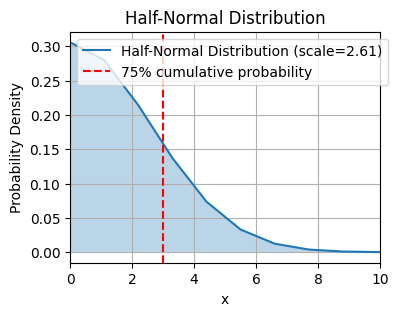

Cumulative probability from 0 to 3: 0.75
Cumulative probability from 0 to 10: 1.00


In [3]:
# Testing code for function 
# Define the desired cumulative probability and range
target_cdf = 0.75  # 75% of values
upper_bound = 3    # From 0 to 3
end_value = 10
# Solve for the scale parameter of the half-normal distribution
scale = upper_bound / halfnorm.ppf(target_cdf)

# Generate data points from the half-normal distribution
x = np.linspace(0, end_value+1, end_value+1)  # Extend slightly beyond upper_bound for visualization
pdf = halfnorm.pdf(x, scale=scale)

# Visualize the distribution
plt.figure(figsize=(4, 3))
plt.plot(x, pdf, label=f"Half-Normal Distribution (scale={scale:.2f})")
plt.fill_between(x, pdf, alpha=0.3)
plt.axvline(upper_bound, color='red', linestyle='--', label='75% cumulative probability')
plt.title("Half-Normal Distribution")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.xlim([0, end_value])
plt.legend()
plt.grid()
plt.show()

# Verify the 75%/100% range
cdf_75 = halfnorm.cdf(upper_bound, scale=scale)
cdf_100 = halfnorm.cdf(end_value, scale=scale)
print(f"Cumulative probability from 0 to {upper_bound}: {cdf_75:.2f}")
print(f"Cumulative probability from 0 to 10: {cdf_100:.2f}")


In [4]:
# make a function to get the distribution
def get_connections_distribution_halfnormal(target_cdf, upper_bound, end_value):
    """
    Function to get a distribution for the number of connections. The underlying assumption is that most households have few connections, but there are some outliers. 
    This uses a half-normal distribution. 
    
    target_cdf: fraction of households that are supposed to have upper_bound or fewer connections
    upper_bound: value where target_cdf % of connections should be in.
    end_value: end of the tail. Maximum number of connections
    """
    
    # Solve for the scale parameter of the half-normal distribution
    scale = upper_bound / halfnorm.ppf(target_cdf)

    # Generate data points from the half-normal distribution
    x = np.linspace(0, end_value+1, end_value+1)  # Extend to the upper bound, +1 because we want it to still have the end_value (because it starts with 0)
    pdf = halfnorm.pdf(x, scale=scale)
    pdf = np.array(pdf)
    #probabilities /= pdf.sum()
    return pdf

In [5]:
# check
probs = get_connections_distribution_halfnormal(0.75, 3, 10)
print(probs, sum(probs))

[3.05948670e-01 2.79908266e-01 2.14346890e-01 1.37389314e-01
 7.37094269e-02 3.30999563e-02 1.24413101e-02 3.91416490e-03
 1.03073359e-03 2.27189391e-04 4.19144696e-05] 1.0620578356097725


In [6]:
p = np.array(probs)
p /= p.sum()  # normalize
values = np.random.choice(11, 1000, p = p) # get values in that distribution

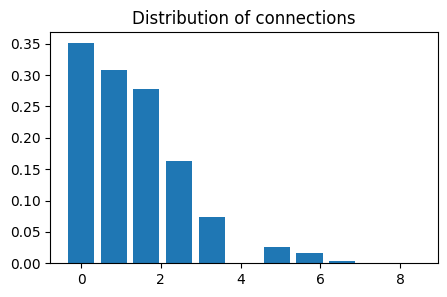

In [7]:
# Checking distribution in plot
fig = plt.figure(figsize =(5, 3))
plt.hist(values, bins = np.array(11), density = True, rwidth = 0.8, align = 'left') 
plt.title("Distribution of connections") 
# show plot
plt.show()

#### Making a graph with that distribution

In [8]:
sum(values)

1573

In [10]:
if sum(values) % 2 == 0:
    pass
elif sum(values) % 2 != 0: # remove a random odd number from the array so it gets an even sum
    odd_indices = np.where(values % 2 != 0)[0] # find all odd numbers in array
    values = np.delete(values, random.choice(odd_indices)) # remove the a random odd number from the vlaues

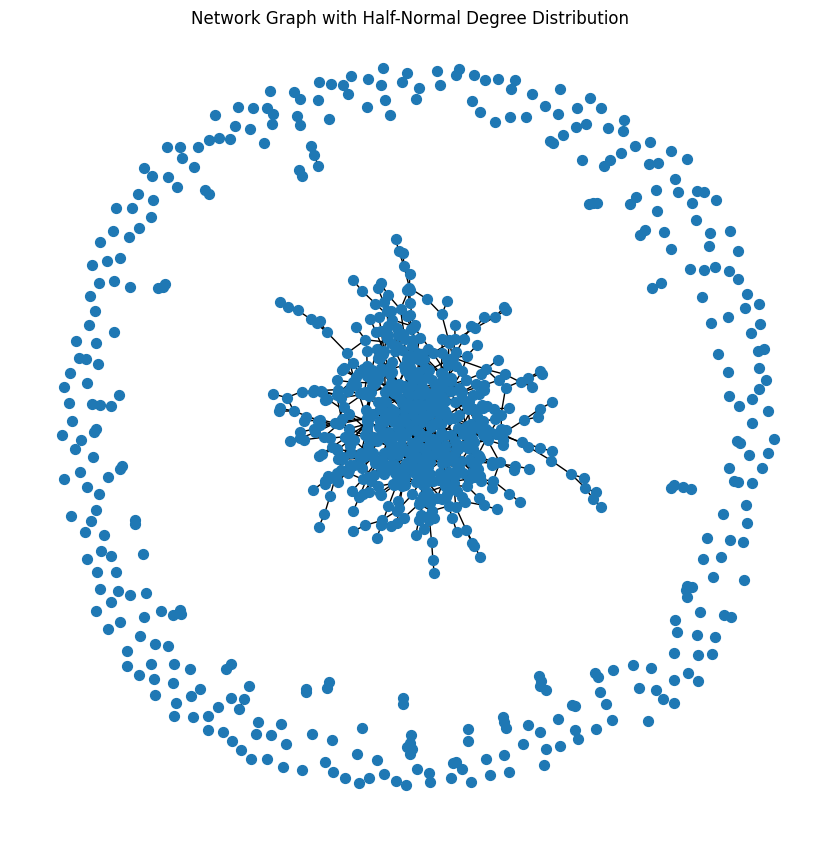

In [11]:
G = nx.configuration_model(values)
G = nx.Graph(G)  # Remove parallel edges and self-loops created by the configuration model
#G = nx.simple_graph(G)  # Ensure the graph is simple

# Visualize the graph
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(G)  # Use a spring layout for visualization
nx.draw(G, pos, node_size=50, with_labels=False)
plt.title("Network Graph with Half-Normal Degree Distribution")
plt.show()

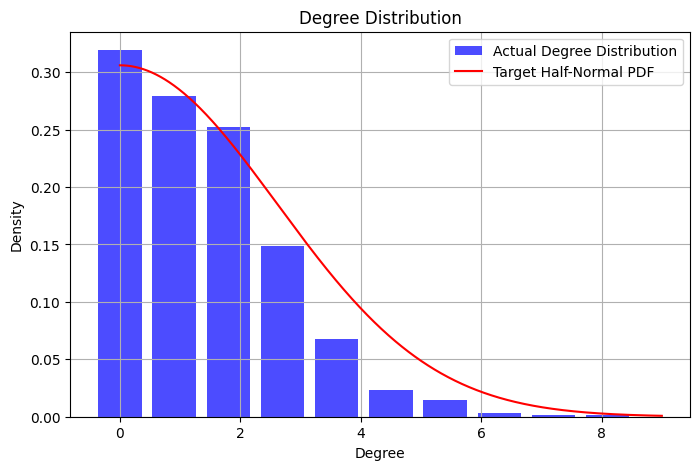

In [23]:
# Verify the degree distribution
actual_degrees = [d for _, d in G.degree()]
plt.figure(figsize=(8, 5))
plt.hist(actual_degrees, bins=10, density=True, alpha=0.7, color='blue', label='Actual Degree Distribution', rwidth = 0.8, align = 'left')
x = np.linspace(0, max(actual_degrees), 1000)
pdf = halfnorm.pdf(x, scale=scale)
plt.plot(x, pdf, color='red', label='Target Half-Normal PDF')
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Density")
plt.legend()
plt.grid()
plt.show()

### Make a function to make the network directly

In [39]:
# make a function to get the distribution
def get_connections_distribution_halfnormal(target_cdf, upper_bound, end_value):
    """
    Function to get a distribution for the number of connections. The underlying assumption is that most households have few connections, but there are some outliers. 
    This uses a half-normal distribution. 
    
    target_cdf: fraction of households that are supposed to have upper_bound or fewer connections
    upper_bound: value where target_cdf % of connections should be in.
    end_value: end of the tail. Maximum number of connections
    """
    
    # Solve for the scale parameter of the half-normal distribution
    scale = upper_bound / halfnorm.ppf(target_cdf)

    # Generate data points from the half-normal distribution
    x = np.linspace(0, end_value+1, end_value+1)  # Extend to the upper bound, +1 because we want it to still have the end_value (because it starts with 0)
    pdf = halfnorm.pdf(x, scale=scale)
    pdf = np.array(pdf)
    #probabilities /= pdf.sum()
    return pdf, x

In [48]:
def construct_network(probability_distribution, max_connections, nr_nodes):
    
    # get connection values from the probability distribution
    p = np.array(probability_distribution)
    p /= p.sum()  # normalize
    values = np.random.choice(max_connections+1, nr_nodes, p = p) # get values in that distribution
    if sum(values) % 2 == 0:
        pass
    elif sum(values) % 2 != 0: # remove a random odd number from the array so it gets an even sum
        odd_indices = np.where(values % 2 != 0)[0] # find all odd numbers in array
        values = np.delete(values, random.choice(odd_indices)) # remove the a random odd number from the vlaues
    # generate graph based on the values
    G = nx.configuration_model(values)
    G = nx.Graph(G)  # Remove parallel edges and self-loops created by the configuration model
    G.remove_edges_from(nx.selfloop_edges(G)) # remove self-loops
    # Verify the degree distribution
    actual_degrees = [d for _, d in G.degree()]
    return G, actual_degrees

Text(0.5, 1.0, 'Degree distribution desired (red) and actual (blue)')

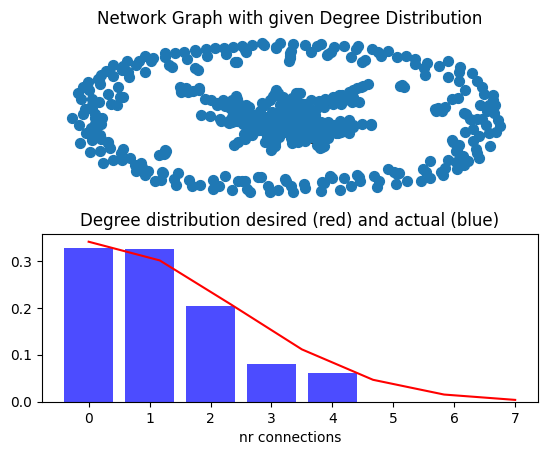

In [49]:
# generate the distribution and then get the network values
max_connections = 6
nr_nodes = 500
pdf, x = get_connections_distribution_halfnormal(0.8, 3, max_connections)
network, degrees = construct_network(pdf, max_connections, nr_nodes)

# Visualize
fig, [ax1, ax2] = plt.subplots(2)
# draw network
nx.draw(network, 
        nx.spring_layout(network),  # Use a spring layout for visualization
        node_size=50, with_labels=False, ax = ax1)
ax1.set_title("Network Graph with given Degree Distribution")

# show degree distribution
ax2.hist(degrees, 
         bins=range(min(degrees), max(degrees), 1), # nr of bins = nr of connections possible
         density=True, alpha=0.7, color='blue', label='Actual Degree Distribution', 
         rwidth = 0.8, 
         align = 'left')
ax2.plot(x, pdf, color='red', label='Target Half-Normal PDF')
ax2.set_xlabel('nr connections')
ax2.set_title("Degree distribution desired (red) and actual (blue)")


### Tweaking the network / network descriptives


In [2]:
def get_connections_distribution_halfnormal(target_cdf, upper_bound, end_value):
    """
    Function to get a distribution for the number of connections. The underlying assumption is that most households have few connections, but there are some outliers. 
    This uses a half-normal distribution. 
    
    target_cdf: fraction of households that are supposed to have upper_bound or fewer connections
    upper_bound: value where target_cdf % of connections should be in.
    end_value: end of the tail. Maximum number of connections
    """
    
    # Solve for the scale parameter of the half-normal distribution
    scale = upper_bound / halfnorm.ppf(target_cdf)

    # Generate data points from the half-normal distribution
    x = np.linspace(0, end_value+1, end_value+1)  # Extend to the upper bound, +1 because we want it to still have the end_value (because it starts with 0)
    pdf = halfnorm.pdf(x, scale=scale)
    pdf = np.array(pdf)
    #probabilities /= pdf.sum()
    return pdf, x

def construct_network(probability_distribution, max_connections, nr_nodes):
    """
    Function to make the network graph given a probability distribution. 
    
    probability_distribution: probability distribution of the node degree
    max_connections: maximun number of connections an agent can have
    nr_nodes: number of nodes wanted for the network
    """
    # get connection values from the probability distribution
    p = np.array(probability_distribution)
    p /= p.sum()  # normalize
    values = np.random.choice(max_connections+1, nr_nodes, p = p) # get values in that distribution
    if sum(values) % 2 == 0:
        pass
    elif sum(values) % 2 != 0: # remove a random odd number from the array so it gets an even sum
        odd_indices = np.where(values % 2 != 0)[0] # find all odd numbers in array
        values = np.delete(values, random.choice(odd_indices)) # remove the a random odd number from the vlaues
    # generate graph based on the values
    G = nx.configuration_model(values)
    G = nx.Graph(G)  # Remove parallel edges and self-loops created by the configuration model
    G.remove_edges_from(nx.selfloop_edges(G)) # remove self-loops
    # Verify the degree distribution
    actual_degrees = [d for _, d in G.degree()]
    return G, actual_degrees

In [3]:
# network structure related
max_nr_connections = 8
perc_until_what_nr_conn = 0.8
most_conn_below = 3
nr_households = 1000

In [4]:
pdf, x_linspace = get_connections_distribution_halfnormal(perc_until_what_nr_conn, most_conn_below, max_nr_connections)
social_network, degrees = construct_network(pdf, max_nr_connections, nr_households)
# if not enough nodes, add a random, unconnected node
if social_network.number_of_nodes() < nr_households:
    nodes_missing = nr_households - social_network.number_of_nodes()
    for n in range(nodes_missing):
        social_network.add_node(social_network.number_of_nodes()+1)
if social_network.number_of_nodes() != nr_households:
    raise ValueError('The number of households and number of nodes of the network are not equal.')
print(social_network)


Graph with 1000 nodes and 666 edges


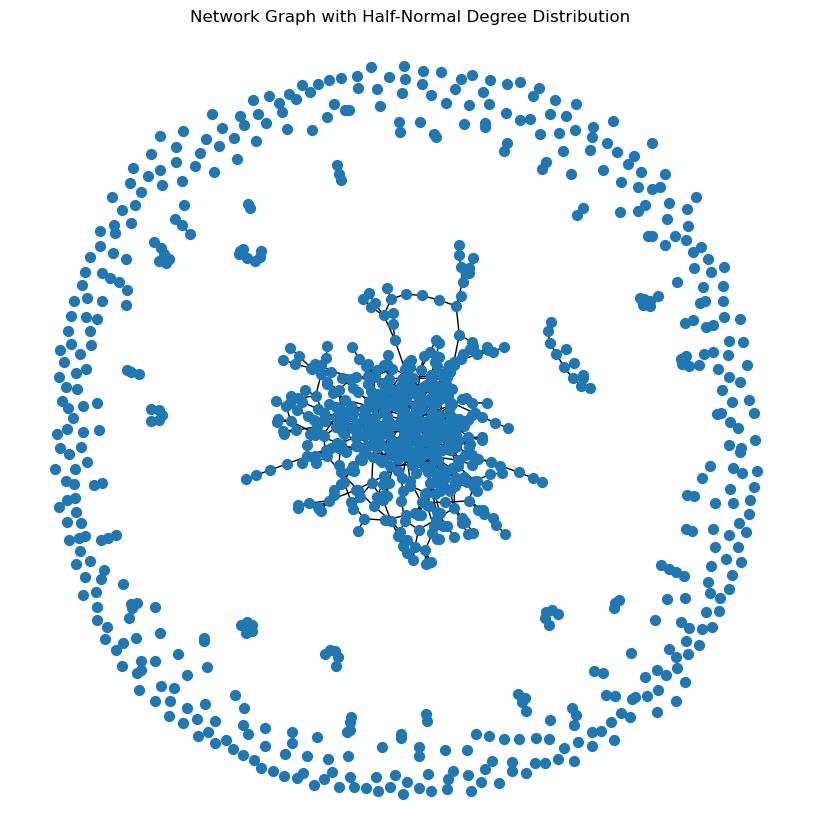

In [5]:
''' Plot of network structure'''
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(social_network)  # Use a spring layout for visualization
nx.draw(social_network, pos, node_size=50, with_labels=False)
plt.title("Network Graph with Half-Normal Degree Distribution")
plt.show()

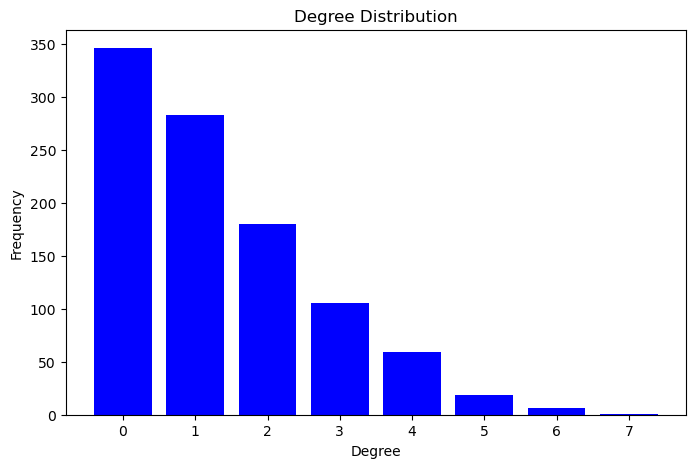

In [6]:
''' Plot of degree distribution'''
plt.figure(figsize=(8, 5))
degree_count = collections.Counter(degrees)
degrees, counts = zip(*degree_count.items())
plt.bar(degrees, counts, color = 'b')
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

In [7]:
num_nodes = social_network.number_of_nodes()
num_edges = social_network.number_of_edges()
is_directed = nx.is_directed(social_network)

In [8]:
num_connected_components = nx.number_connected_components(social_network) if not is_directed else nx.number_strongly_connected_components(social_network)
num_connected_components

401

In [9]:
connected_components = list(nx.connected_components(social_network)) if not is_directed else list(nx.strongly_connected_components(social_network))
connected_components

[{0},
 {1},
 {2},
 {3,
  4,
  5,
  7,
  8,
  15,
  16,
  19,
  24,
  31,
  33,
  36,
  37,
  39,
  40,
  44,
  45,
  50,
  52,
  54,
  56,
  57,
  58,
  60,
  62,
  64,
  66,
  67,
  68,
  69,
  72,
  75,
  76,
  78,
  79,
  81,
  82,
  85,
  86,
  88,
  90,
  91,
  92,
  93,
  98,
  99,
  101,
  104,
  105,
  108,
  109,
  111,
  112,
  114,
  115,
  116,
  117,
  120,
  121,
  122,
  124,
  127,
  128,
  130,
  132,
  133,
  134,
  135,
  138,
  139,
  140,
  141,
  143,
  144,
  147,
  148,
  149,
  150,
  152,
  154,
  158,
  159,
  160,
  161,
  167,
  170,
  171,
  172,
  173,
  175,
  177,
  182,
  185,
  189,
  190,
  192,
  195,
  196,
  197,
  198,
  204,
  207,
  209,
  211,
  212,
  213,
  214,
  217,
  218,
  222,
  226,
  229,
  230,
  231,
  234,
  237,
  240,
  246,
  248,
  249,
  256,
  257,
  260,
  262,
  265,
  270,
  271,
  274,
  276,
  277,
  280,
  281,
  282,
  285,
  286,
  287,
  288,
  290,
  292,
  293,
  297,
  298,
  301,
  302,
  303,
  306,
  308,
  31

In [10]:
degree_sequence = [d for n, d in social_network.degree()]
avg_degree = sum(degree_sequence) / num_nodes
avg_degree

1.332

In [11]:
avg_clustering = nx.average_clustering(social_network)
avg_clustering

0.001

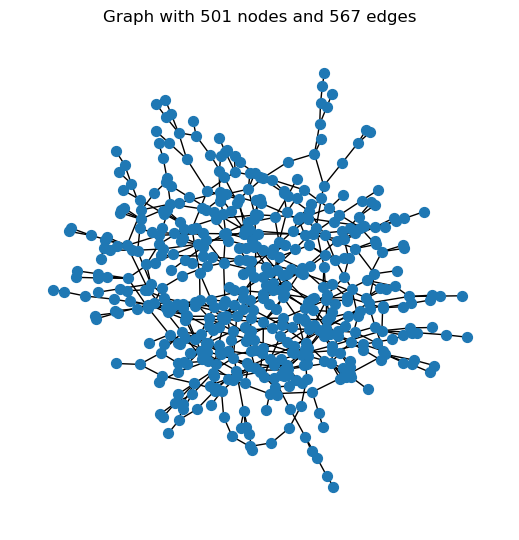

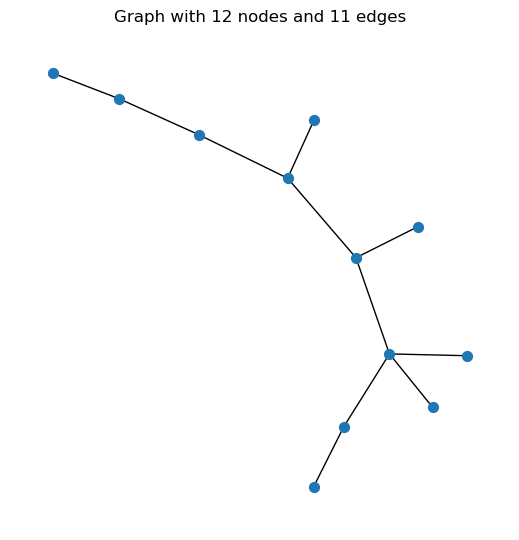

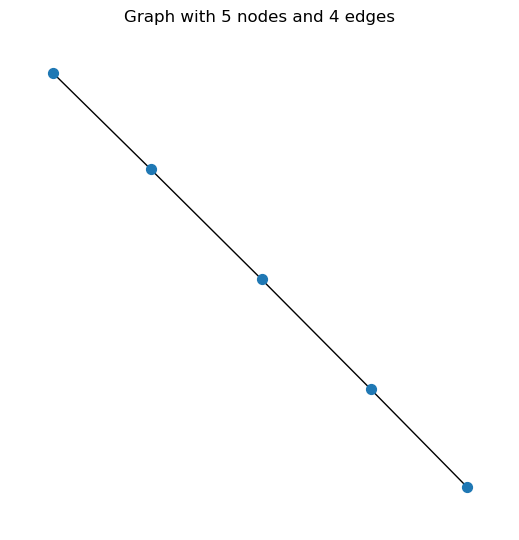

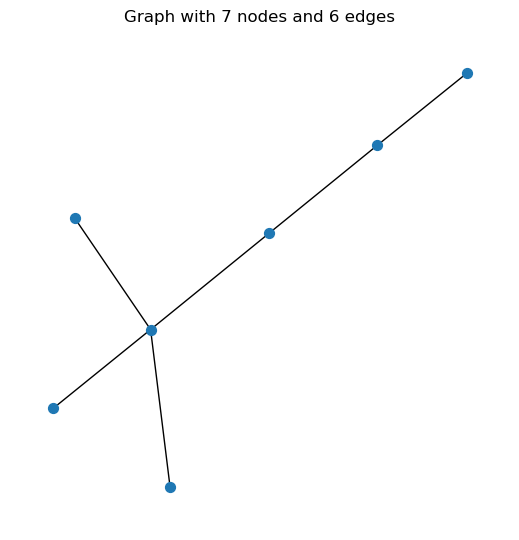

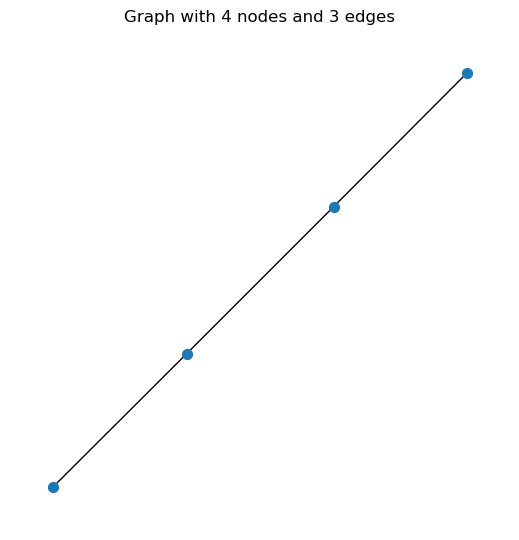

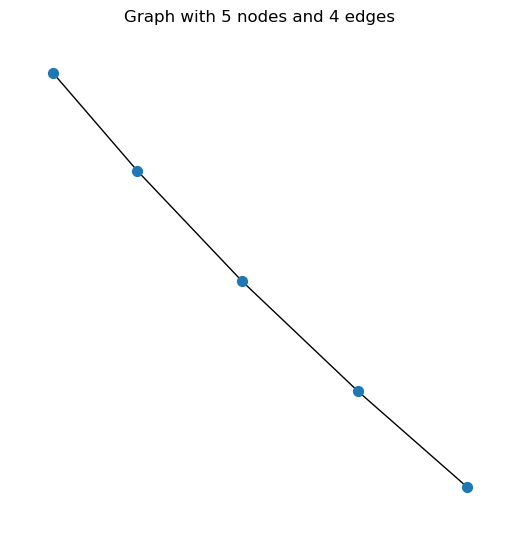

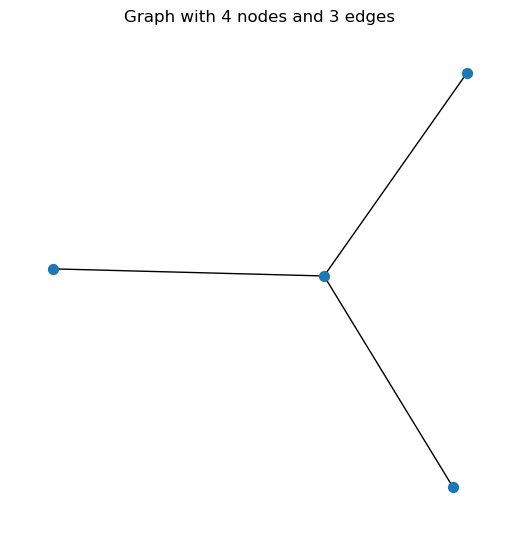

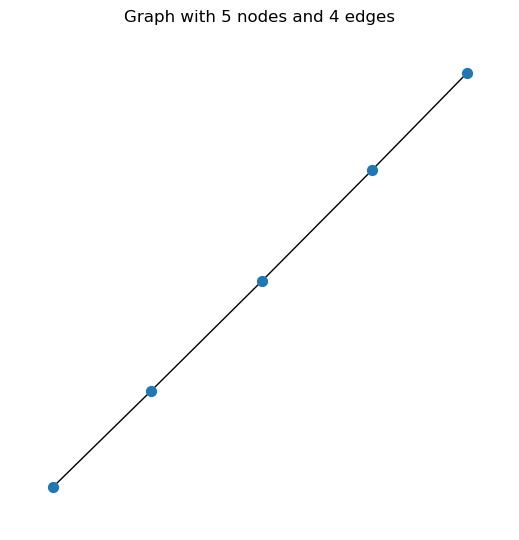

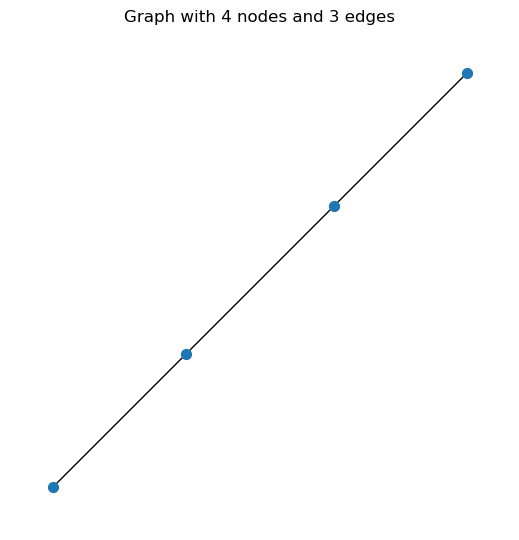

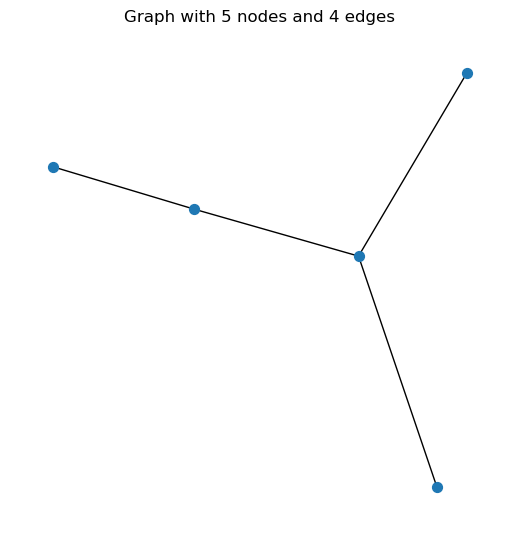

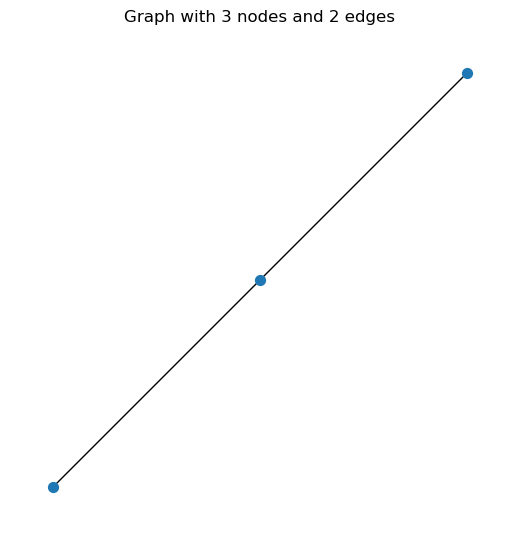

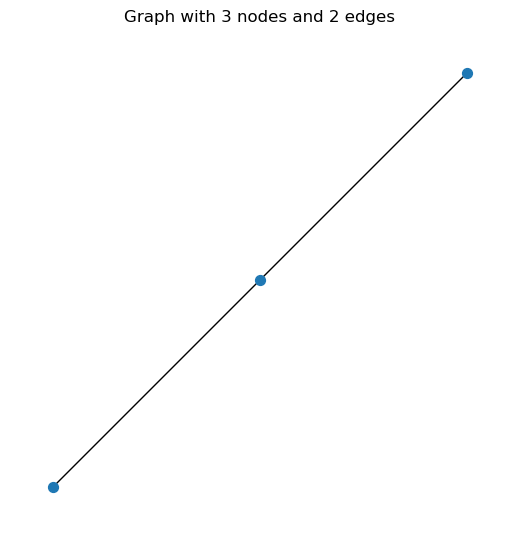

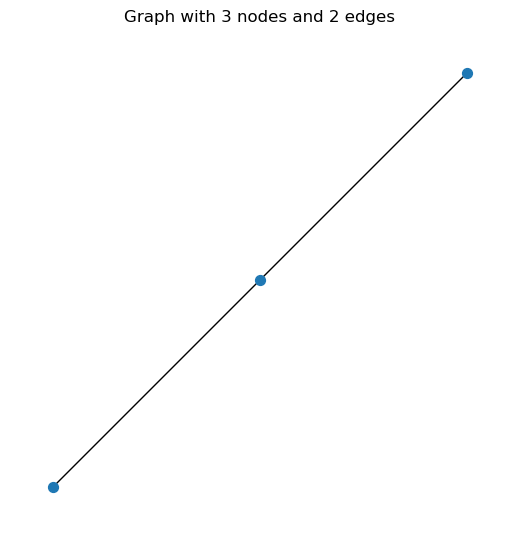

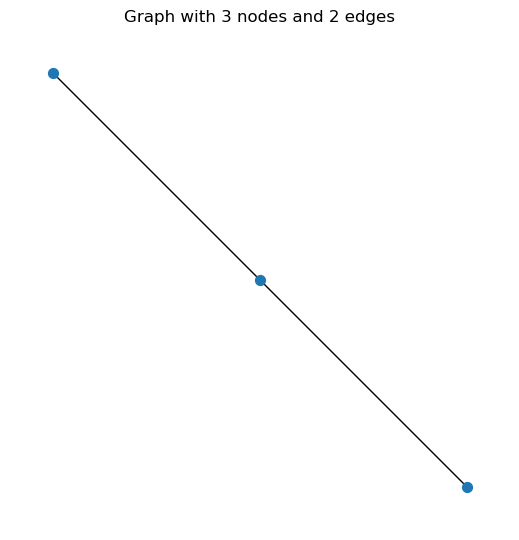

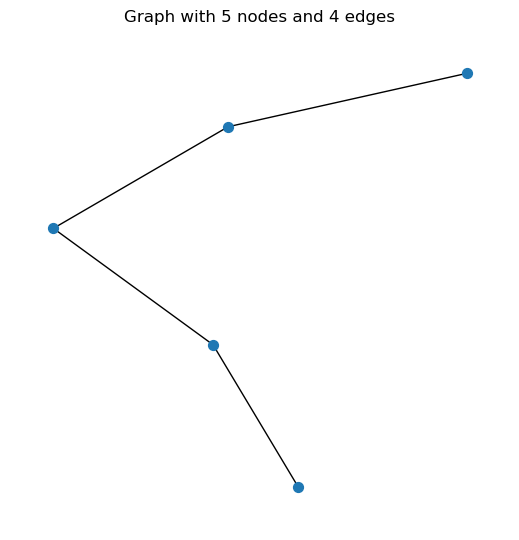

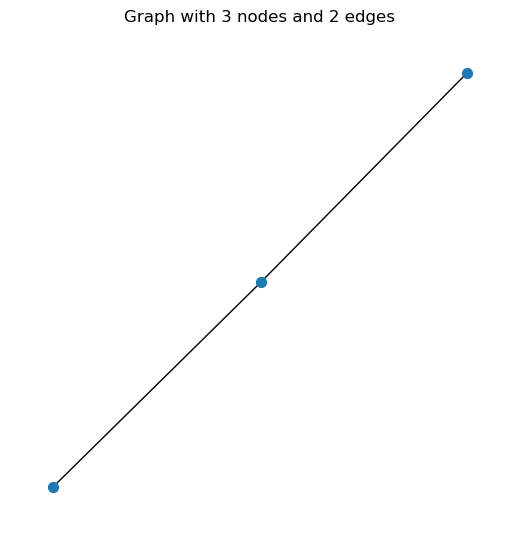

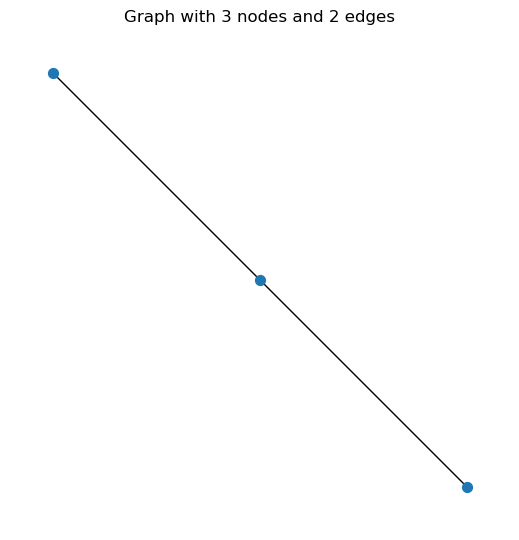

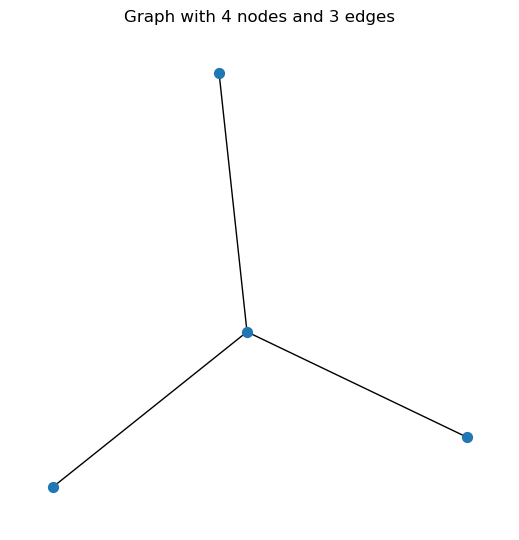

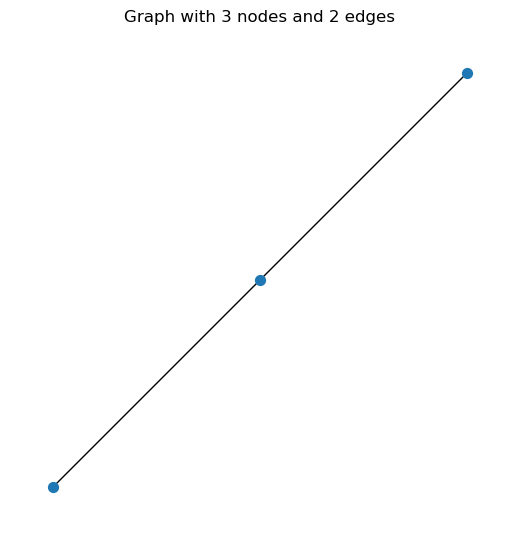

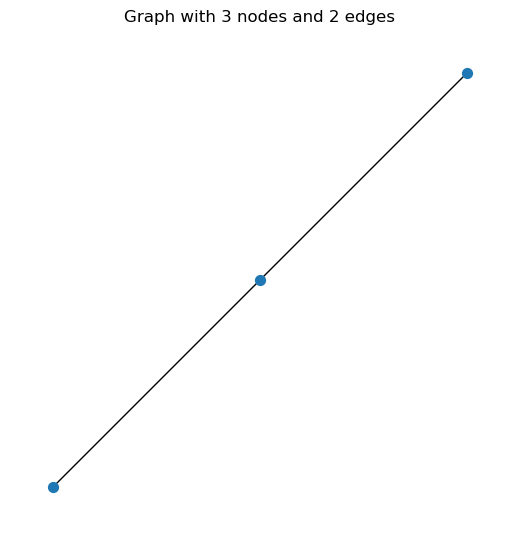

In [45]:
diameters = []
for component in connected_components:
    subgraph = social_network.subgraph(component)
    if subgraph.number_of_nodes() > 2:
        plt.figure(figsize=(5, 5))
        pos = nx.spring_layout(subgraph)  # Use a spring layout for visualization
        nx.draw(subgraph, node_size=50, with_labels=False)
        plt.title(subgraph)
        plt.show()
        #print(subgraph)
    if nx.is_connected(subgraph):  # Ensure the subgraph is connected
        diameters.append(nx.diameter(subgraph))

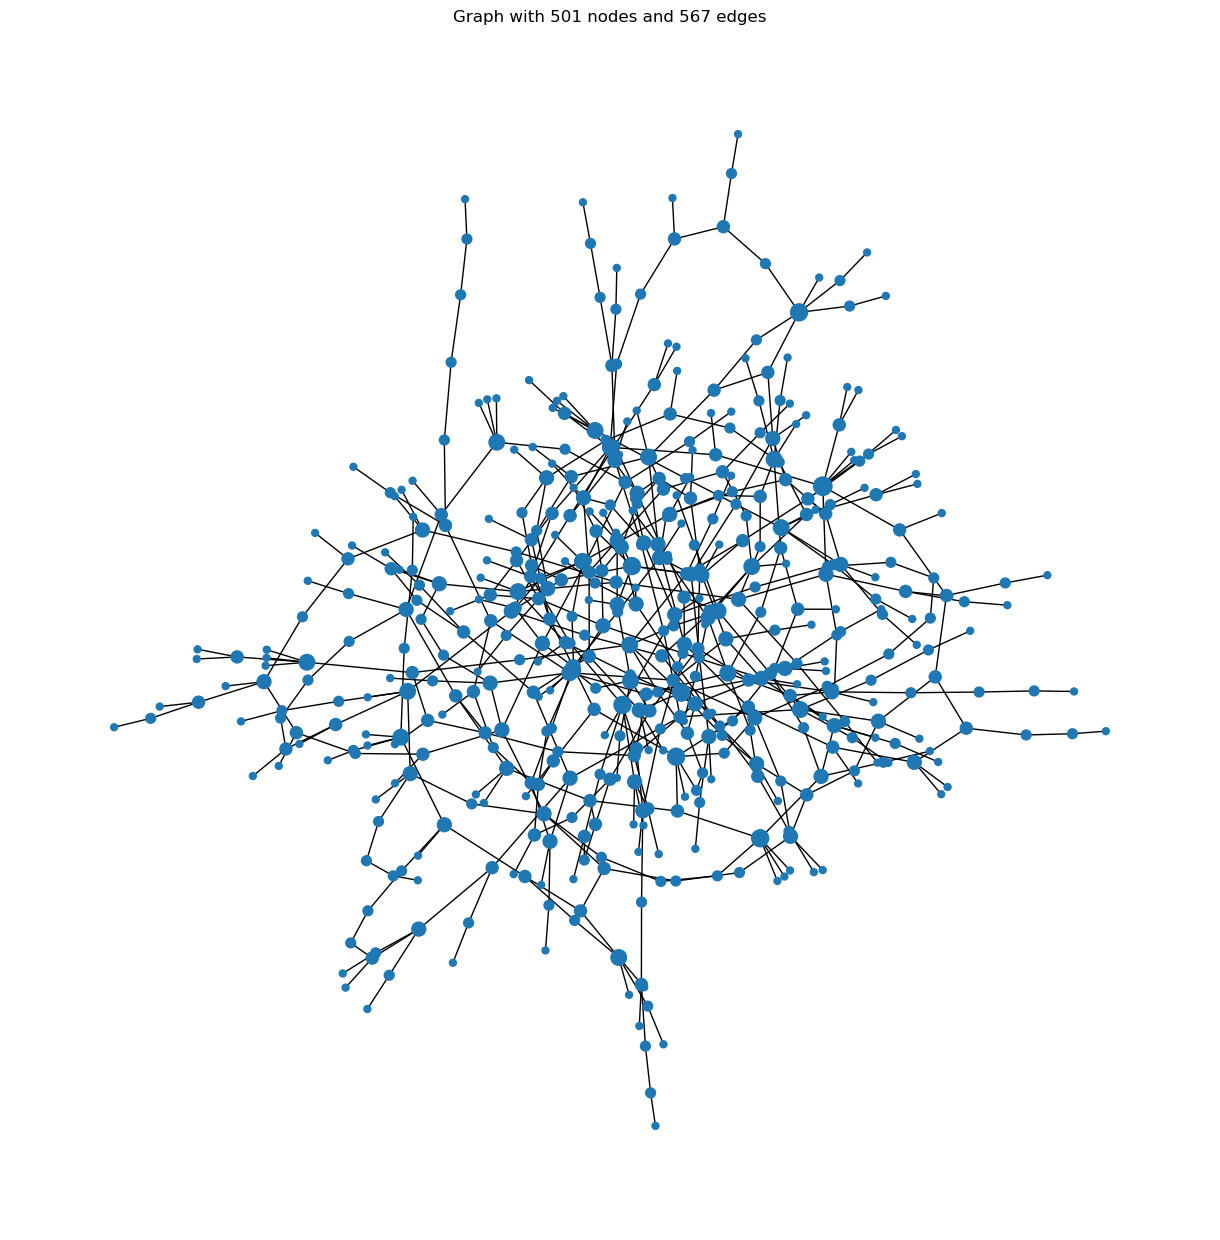

In [44]:
for component in connected_components:
    subgraph = social_network.subgraph(component)
    if subgraph.number_of_nodes() > 20:
        plt.figure(figsize=(12, 12))
        degrees = dict(subgraph.degree())
        node_size = [v * 25 for v in degrees.values()]
        nx.draw(subgraph, pos = nx.spring_layout(subgraph), node_size=node_size, with_labels=False) # spectral_layout, spring_layout, kamada_kawai_layout
        plt.title(subgraph)
        plt.show()

In [13]:
collections.Counter(diameters)

Counter({0: 347, 1: 34, 2: 10, 4: 5, 3: 3, 22: 1, 7: 1})

In [14]:
density = nx.density(social_network)
density

0.0013333333333333333

In [15]:
degree_centrality = nx.degree_centrality(social_network)
degree_centrality

{0: 0.0,
 1: 0.0,
 2: 0.0,
 3: 0.001001001001001001,
 4: 0.004004004004004004,
 5: 0.003003003003003003,
 6: 0.0,
 7: 0.001001001001001001,
 8: 0.001001001001001001,
 9: 0.001001001001001001,
 10: 0.0,
 11: 0.0,
 12: 0.0,
 13: 0.0,
 14: 0.0,
 15: 0.002002002002002002,
 16: 0.002002002002002002,
 17: 0.0,
 18: 0.0,
 19: 0.004004004004004004,
 20: 0.0,
 21: 0.0,
 22: 0.001001001001001001,
 23: 0.0,
 24: 0.002002002002002002,
 25: 0.0,
 26: 0.001001001001001001,
 27: 0.0,
 28: 0.0,
 29: 0.0,
 30: 0.001001001001001001,
 31: 0.002002002002002002,
 32: 0.0,
 33: 0.005005005005005005,
 34: 0.0,
 35: 0.0,
 36: 0.001001001001001001,
 37: 0.001001001001001001,
 38: 0.0,
 39: 0.004004004004004004,
 40: 0.001001001001001001,
 41: 0.0,
 42: 0.001001001001001001,
 43: 0.001001001001001001,
 44: 0.002002002002002002,
 45: 0.001001001001001001,
 46: 0.0,
 47: 0.004004004004004004,
 48: 0.0,
 49: 0.0,
 50: 0.001001001001001001,
 51: 0.001001001001001001,
 52: 0.001001001001001001,
 53: 0.0,
 54: 0.0010

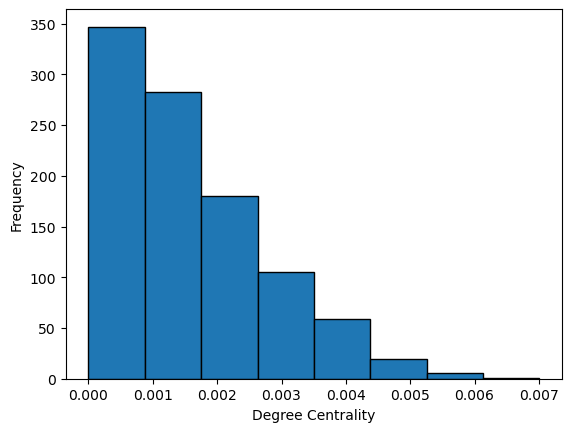

In [16]:
# Extract the values from the dictionary
values = list(degree_centrality.values())

# Create the histogram
plt.hist(values, bins=8, edgecolor='black')  # You can adjust the number of bins as needed

# Add labels and title
plt.xlabel('Degree Centrality')
plt.ylabel('Frequency')

# Show the plot
plt.show()

In [17]:
betweenness_centrality = nx.betweenness_centrality(social_network)
betweenness_centrality

{0: 0.0,
 1: 0.0,
 2: 0.0,
 3: 0.0,
 4: 0.009820780796064695,
 5: 0.007020218042262127,
 6: 0.0,
 7: 0.0,
 8: 0.0,
 9: 0.0,
 10: 0.0,
 11: 0.0,
 12: 0.0,
 13: 0.0,
 14: 0.0,
 15: 0.004533892610044915,
 16: 0.0019979899739418776,
 17: 0.0,
 18: 0.0,
 19: 0.008597408363607426,
 20: 0.0,
 21: 0.0,
 22: 0.0,
 23: 0.0,
 24: 0.001410506476193405,
 25: 0.0,
 26: 0.0,
 27: 0.0,
 28: 0.0,
 29: 0.0,
 30: 0.0,
 31: 0.006461492188501762,
 32: 0.0,
 33: 0.01660966243464574,
 34: 0.0,
 35: 0.0,
 36: 0.0,
 37: 0.0,
 38: 0.0,
 39: 0.009789536331509169,
 40: 0.0,
 41: 0.0,
 42: 0.0,
 43: 0.0,
 44: 0.0026956816535974857,
 45: 0.0,
 46: 0.0,
 47: 2.4072168360745514e-05,
 48: 0.0,
 49: 0.0,
 50: 0.0,
 51: 0.0,
 52: 0.0,
 53: 0.0,
 54: 0.0,
 55: 0.0,
 56: 0.001001001001001001,
 57: 0.007349264045990839,
 58: 0.0,
 59: 0.0,
 60: 0.001001001001001001,
 61: 0.0,
 62: 0.0,
 63: 0.0,
 64: 0.0,
 65: 0.0,
 66: 0.011720203837772308,
 67: 0.001001001001001001,
 68: 0.0,
 69: 0.0,
 70: 0.0,
 71: 0.0,
 72: 0.00100100

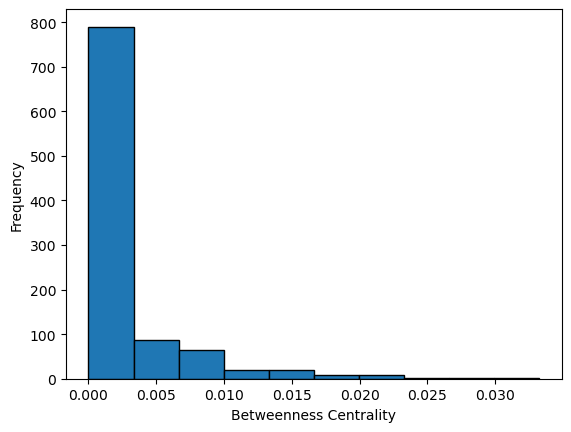

In [18]:
# Extract the values from the dictionary
values = list(betweenness_centrality.values())

# Create the histogram
plt.hist(values, bins=10, edgecolor='black')  # You can adjust the number of bins as needed

# Add labels and title
plt.xlabel('Betweenness Centrality')
plt.ylabel('Frequency')

# Show the plot
plt.show()